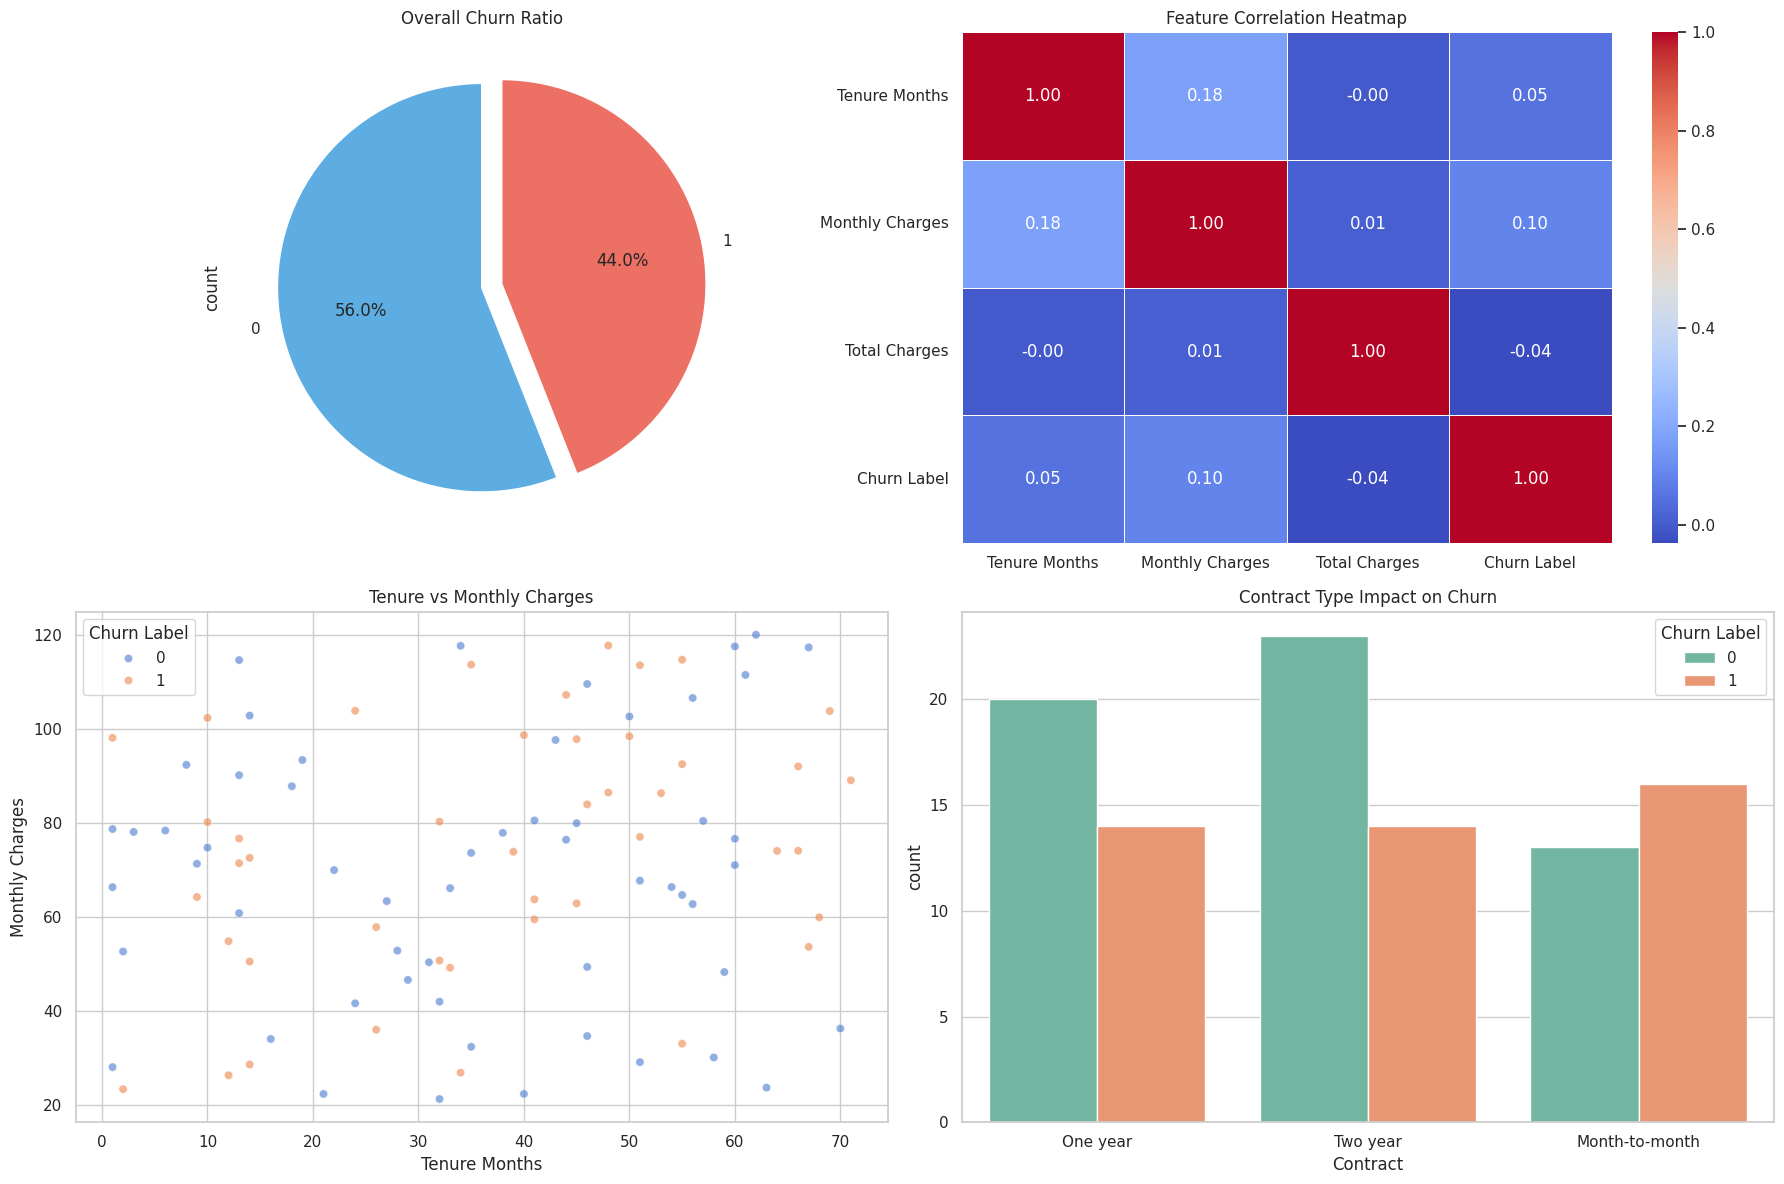

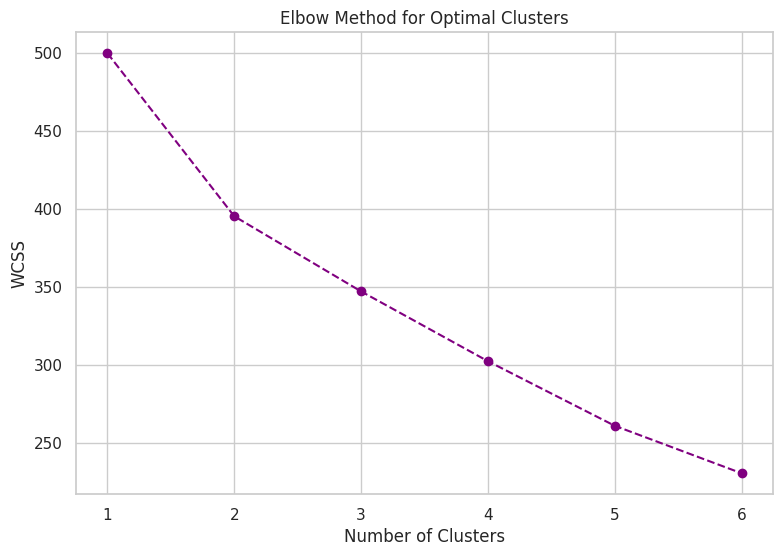

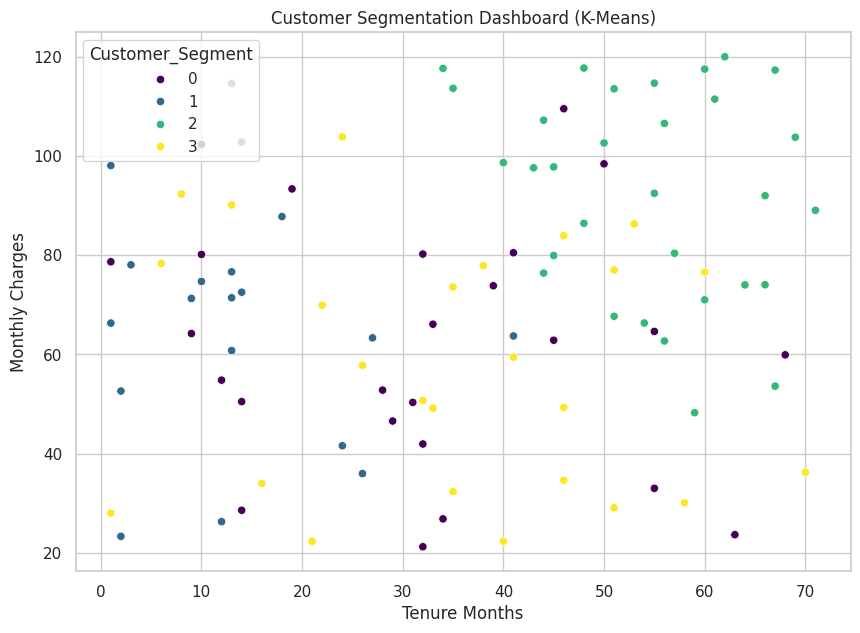


Model Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.64      0.61        11
           1       0.50      0.44      0.47         9

    accuracy                           0.55        20
   macro avg       0.54      0.54      0.54        20
weighted avg       0.55      0.55      0.55        20



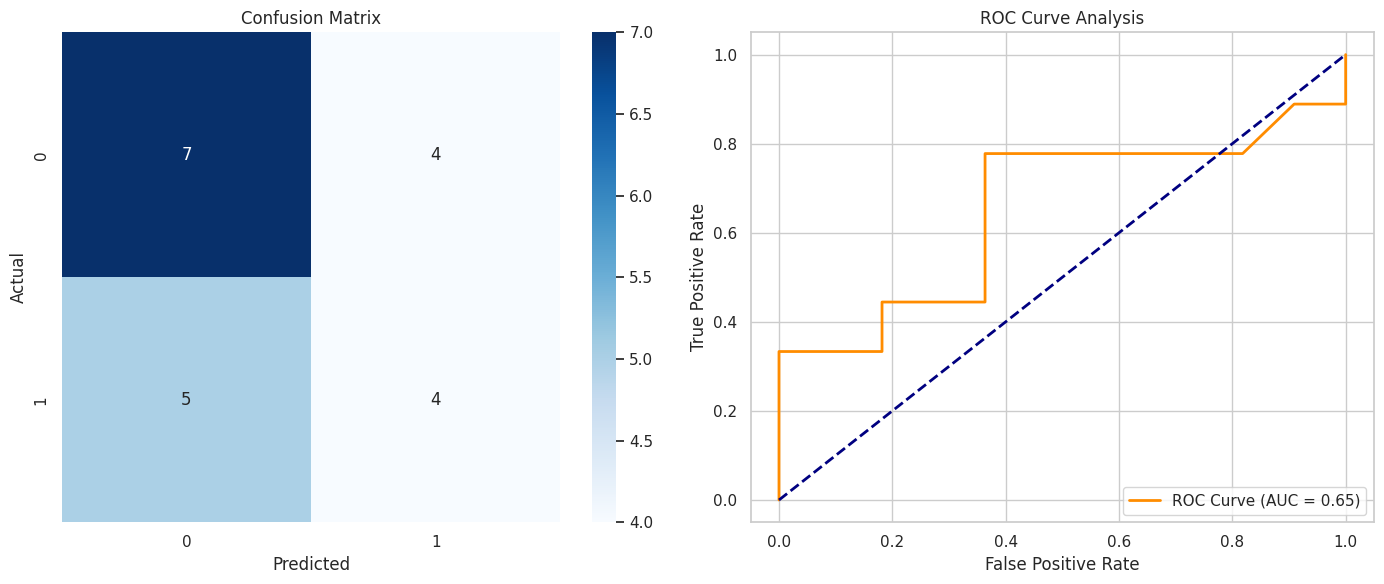

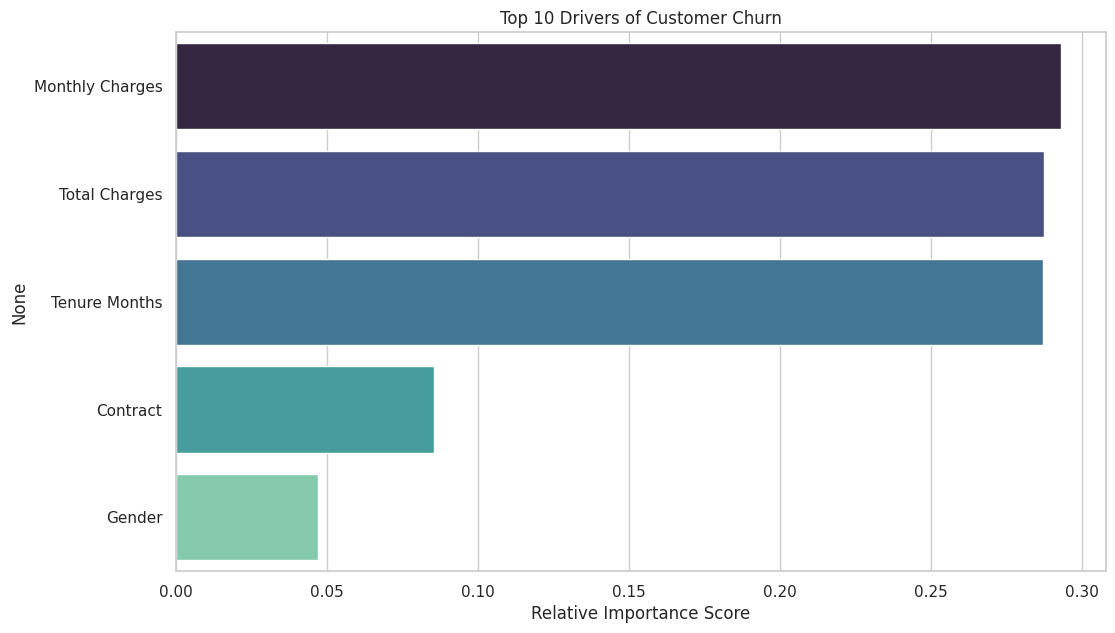

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")

# --- Added to resolve NameError: name 'df' is not defined ---
# This is a placeholder for your actual data loading.
# Replace this with your own code to load your DataFrame, e.g., pd.read_csv('your_data.csv')
data = {
    'customerID': [f'C{i}' for i in range(1, 101)],
    'Gender': np.random.choice(['Male', 'Female'], 100),
    'Tenure Months': np.random.randint(1, 73, 100),
    'Monthly Charges': np.random.uniform(20, 120, 100),
    'Total Charges': np.random.uniform(50, 5000, 100).astype(str),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], 100),
    'Churn Label': np.random.choice([0, 1], 100) # 0 for no churn, 1 for churn
}
df = pd.DataFrame(data)

# Introduce some ' ' in 'Total Charges' for testing the preprocessing step
for _ in range(5):
    idx = np.random.randint(0, len(df))
    df.loc[idx, 'Total Charges'] = ' '

# Data Preprocessing
if 'Total Charges' in df.columns:
    df['Total Charges'] = df['Total Charges'].replace(' ', np.nan)
    df['Total Charges'] = df['Total Charges'].astype(float)
    df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# Exploratory Data Analysis Dashboard
plt.figure(figsize=(18, 12)) # Increased figure size

plt.subplot(2, 2, 1)
if 'Churn Label' in df.columns:
    df['Churn Label'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#5dade2', '#ec7063'], explode=(0, 0.1))
    plt.title('Overall Churn Ratio')
else:
    plt.title('Overall Churn Ratio (Churn Label not found)')

plt.subplot(2, 2, 2)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')

plt.subplot(2, 2, 3)
if 'Tenure Months' in df.columns and 'Monthly Charges' in df.columns and 'Churn Label' in df.columns:
    sns.scatterplot(data=df, x='Tenure Months', y='Monthly Charges', hue='Churn Label', alpha=0.6)
    plt.title('Tenure vs Monthly Charges')
else:
    plt.title('Tenure vs Monthly Charges (Required columns not found)')

plt.subplot(2, 2, 4)
if 'Contract' in df.columns and 'Churn Label' in df.columns:
    sns.countplot(data=df, x='Contract', hue='Churn Label', palette='Set2')
    plt.title('Contract Type Impact on Churn')
else:
    plt.title('Contract Type Impact on Churn (Required columns not found)')

plt.tight_layout()
plt.show()

# Categorical Encoding
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if col != 'Churn Label':
        df[col] = le.fit_transform(df[col])

# Handle 'Churn Label' separately
if 'Churn Label' in df.columns:
    df['Churn Label'] = le.fit_transform(df['Churn Label'])

    # Scaling for Clustering & Modeling
    scaler = StandardScaler()
    X = df.drop(columns=['Churn Label'])
    y = df['Churn Label']
    X_scaled = scaler.fit_transform(X)

    # Optimal K Search (Elbow Method)
    wcss = []
    for i in range(1, 7):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)

    plt.figure(figsize=(9, 6)) # Increased figure size
    plt.plot(range(1, 7), wcss, marker='o', linestyle='--', color='purple')
    plt.title('Elbow Method for Optimal Clusters')
    plt.xlabel('Number of Clusters')
    plt.ylabel('WCSS')
    plt.show()

    # K-Means Clustering execution
    if X_scaled.shape[1] > 0: # Ensure X_scaled is not empty
        kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
        df['Customer_Segment'] = kmeans_final.fit_predict(X_scaled)

        plt.figure(figsize=(10, 7)) # Increased figure size
        if 'Tenure Months' in df.columns and 'Monthly Charges' in df.columns:
            sns.scatterplot(data=df, x='Tenure Months', y='Monthly Charges', hue='Customer_Segment', palette='viridis', legend='full')
            plt.title('Customer Segmentation Dashboard (K-Means)')
            plt.show()
        else:
            plt.title('Customer Segmentation Dashboard (Required columns not found)')

    # Supervised Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Random Forest Hyperparameter Tuning
    param_dist = {
        'n_estimators': [50, 100, 150],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }

    rf = RandomForestClassifier(random_state=42)
    rf_tuned = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=5, cv=3, random_state=42)
    rf_tuned.fit(X_train, y_train)

    best_model = rf_tuned.best_estimator_
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    # Model Evaluation
    print("\nModel Classification Report:")
    print(classification_report(y_test, y_pred))

    # Performance Visualizations
    plt.figure(figsize=(14, 6)) # Increased figure size

    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Analysis')
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    # Feature Importance extraction
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(12, 7)) # Increased figure size
    sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='mako')
    plt.title('Top 10 Drivers of Customer Churn')
    plt.xlabel('Relative Importance Score')
    plt.show()
